In [1]:
import h3

import sys

import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import einops
import numpy as np
import sys
sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
import torch

from model.layers.encoder import *
from model.layers.decoder import *
from model.layers.processor import *
from model.layers.graph_net_block import *
from model.data.dataloader_graphnet import *
from model.data.load_data import *
from model.forecast import GraphSatelliteForecaster
import torch.optim as optim
import pytorch_lightning as pl
from sklearn.metrics import mean_squared_error, r2_score
import time
import os
import pickle
import json

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# load data (manually)

In [2]:
# load train and test data to train a model
# date can be a single year (eg year="2014"), a more specific date (eg year="2014", month="05"), or a wider search (eg year="201[4-5]" loads both 2014 and 2015)
data = LoadSatelliteData(year="2014", month="01", region="BRAZIL", freq=30, metsize=50, size =50, topog="default", verbose=True, met_datadir="/group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_")

Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201401*.nc
reduced the number of datapoints by frequency 30
Cutting footprints to size
Loading meteorology from /group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_201401*.nc
met levels []
met and fp_data have different timeframes! could be because either is already frequency-reduced or due to selected time indeces.
there are 1449 met timepoints, 49 footprint timepoints, and 49 are in common. reducing both to the common points - could go wrong but shouldnt!
loading topography from /group/chemistry/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
All data loaded


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_

### exploring data object

In [12]:
# data object has attribute met, cut around measurement point
# measurement point is at 25,25 in this case
data.met

<xarray.Dataset>
Dimensions:                              (levels: 7, lat: 50, lon: 50, time: 49)
Coordinates:
    lat_coords                           (time, lat) float64 -5.289 ... -21.9
    lon_coords                           (time, lon) float64 -59.3 ... -45.92
  * lat                                  (lat) int64 0 1 2 3 4 ... 46 47 48 49
  * lon                                  (lon) int64 0 1 2 3 4 ... 46 47 48 49
  * time                                 (time) datetime64[ns] 2014-01-01T16:...
  * levels                               (levels) int64 3 9 15 21 30 42 51
Data variables:
    air_pressure                         (levels, lat, lon, time) float64 9.8...
    air_temperature                      (levels, lat, lon, time) float64 303...
    atmosphere_boundary_layer_thickness  (lat, lon, time) float64 1.356e+03 ....
    surface_air_pressure                 (lat, lon, time) float64 1.001e+05 ....
    upward_air_velocity                  (levels, lat, lon, time) float64 0.0...
    x_wind                               (levels, lat, lon, time) float64 -3....
    y_wind                               (levels, lat, lon, time) float64 -2....
    wind_angle                           (levels, lat, lon, time) float64 0.9...
    wind_speed                           (levels, lat, lon, time) float64 3.8...

In [13]:
# data object stores full footprints in the original format as fp_data_full
data.fp_data_full

<xarray.Dataset>
Dimensions:               (time: 49, lon: 190, lat: 357, lev: 1, height: 20)
Coordinates:
  * time                  (time) datetime64[ns] 2014-01-01T16:04:56.500000 .....
  * lon                   (lon) float32 -91.33 -90.98 -90.62 ... -25.15 -24.8
  * lat                   (lat) float32 -60.98 -60.75 -60.51 ... 22.09 22.32
  * lev                   (lev) |S1 b'c'
  * height                (height) float32 500.0 1.5e+03 ... 1.85e+04 1.95e+04
Data variables:
    fp                    (lat, lon, time) float32 0.0 0.0 ... 7.629e-06
    temperature           (time) float32 27.82 25.49 34.76 ... 25.18 16.78 29.71
    pressure              (time) float32 992.5 994.5 962.0 ... 996.5 877.3 967.9
    wind_speed            (time) float32 7.329 4.696 4.379 ... 11.03 3.128 4.244
    wind_direction        (time) float32 98.41 86.92 5.477 ... 5.745 278.8 320.4
    PBLH                  (time) float32 977.7 708.5 ... 1.196e+03 1.4e+03
    release_lon           (time) float32 -50.55 -35.03 -62.5 ... -71.06 -54.31
    release_lat           (time) float32 0.649 -11.85 -27.5 ... -28.87 -27.5
    particle_locations_n  (height, lon, time) float32 0.0 0.0 0.0 ... 0.0 0.0
    particle_locations_e  (height, lat, time) float32 0.0 0.0 0.0 ... 0.0 0.0
    particle_locations_s  (height, lon, time) float32 0.0 0.0 0.0 ... 0.0 0.0
    particle_locations_w  (height, lat, time) float32 0.0 0.0 0.0 ... 0.0 0.0
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-14 13:21:46.638679

In [16]:
# data object stores ready-to-use cut footprints as an array of shape (time, size*size)
np.shape(data.fp_data)

(49, 2500)

### getting inputs

In [3]:
# to train, set up both the training and testing datasets manually
# skip to "predicting" if not training
others =["sin_lat_coords", "sin_lon_coords", "cos_lat_coords", "cos_lon_coords", "lat_coords", "lon_coords", "distance_centre", "x_coords", "y_coords"]
topog=True
variables_with_past = {"x_wind":[3,9,15,21,30,42,51], "wind_speed":[3,30,51], "wind_angle":[3,30,51], "y_wind":[3,9,15,21,30,42,51], "upward_air_velocity":[3,9,15,21,30,42,51], "air_temperature":[3,9,15,21,30,42,51], "air_pressure":[3,9,15,21,30,42,51], "atmosphere_boundary_layer_thickness":[0], "surface_air_pressure":[0]}
jumps = [6,12]
variables_without_past = {}

In [4]:
# fetch the inputs
# grid is a lat-lon grid to build the mesh with
grid, idx_grid, inputs, names, data = get_all_inputs_graphnet_satellite_v4(data, variables_with_past, jumps, variables_without_past, topog=topog, others=others, return_idx=True, centered_coords=True)

hours back in time: [0, 6, 12]
49
0 49 50
6 49 50
12 49 50
(50, 50, 49)


In [10]:
# dict names contains a list of dicts with info about each input
names

[{'var': 'x_wind', 'level': 3, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 9, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 15, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 21, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 30, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 42, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 51, 'type': '3D', 'time': 't-0'},
 {'var': 'x_wind', 'level': 3, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 9, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 15, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 21, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 30, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 42, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 51, 'type': '3D', 'time': 't-6'},
 {'var': 'x_wind', 'level': 3, 'type': '3D', 'time': 't-12'},
 {'var': 'x_wind', 'level': 9, 'type': '3D', 'time': 't-12'},
 {'var': 'x_

In [5]:
train_dataset = FootprintsDatasetV2(inputs, data.fp_data, input_names=names, input_transforms = ["clever_transform_2"], output_transforms = ["boxcox"])
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)

50
{}
{}


init boxcox
transforming


In [17]:
# if we have a test dataset, we can transform the data using the transforms trained on the training data by passing test_mode=train_dataset.transform_parameters
## note that we haven't created test_data object or test_inputs so this won't run!
test_dataset = FootprintsDatasetV2(test_inputs, test_data.fp_data, input_names=names, test_mode=train_dataset.transform_parameters, input_transforms = ["clever_transform_2"], output_transforms = ["boxcox"])

### looking at the data and the transforms

- train_dataset.fp is a tensor with the transformed footprints
- train_dataset.fp_untransformed is the original fp array

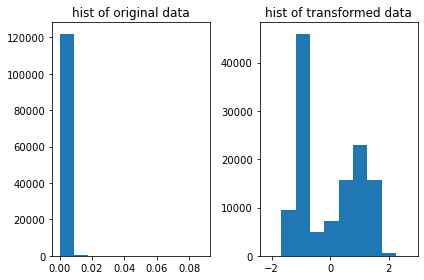

In [28]:
fig, ax = plt.subplots(1,2)
ax[0].hist(train_dataset.fp_untransformed.flatten())
ax[0].set_title("hist of original data")
ax[1].hist(train_dataset.fp.detach().numpy().flatten())
ax[1].set_title("hist of transformed data")
plt.tight_layout()
plt.show()

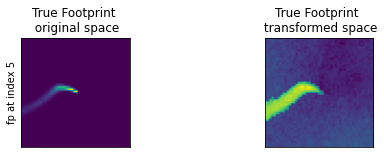

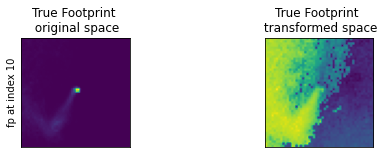

In [14]:
# plot footprint at a particular index 
idx = 5
train_dataset.plot_footprints(idx)
train_dataset.plot_footprints(idx+5)

# load data and predict - from file

note that only the model satellite_50x50_distance can be used for this, the previous model is loaded differently! will add a couple extra models soon for comparison

In [13]:
def load_file(file_name, file_path):
    if not file_path:
       # change this to your default path!
       file_path ="/user/work/ef17148/GCN/graphnet/graph_weather/train_satellite_files/"
    file_path = f"{file_path}{file_name}"
    try:
        with open(file_path, 'r') as file:
            if file_path.endswith('.json'):
                data = json.load(file)
            else:
                data = file.read()
                data = json.loads(data)
        return data
    except FileNotFoundError:
        print(f"File not found: {file_path}")
        return None
    except Exception as e:
        print(f"An error occurred while loading the file: {str(e)}")
        return None
    
def getint(name):
    num = name.split('_')[-1]
    num = num.split('.')[0]
    return int(num)

In [14]:
# load parameter file
parameters = load_file("training_settings_satellite_50x50_distance.json", "/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/trained_models/satellite_50x50_distance/")

In [15]:
train_load_data = copy.deepcopy(parameters["train_load_data"])
# load train parameters and upload with any changes to test data
test_load_data = copy.deepcopy(parameters["train_load_data"])
test_load_data.update(parameters["test_load_data"])
print(train_load_data)
print(test_load_data)

# adding this manually so predictions are only for one month
test_load_data["month"] = "02"

# no need to load training data as the model is already trained! 
#data = LoadSatelliteData(**train_load_data)

test_data = LoadSatelliteData(**test_load_data)

{'year': '201[4-5]', 'freq': 3, 'region': 'BRAZIL', 'metsize': 50, 'size': 50, 'verbose': True, 'topog': 'default', 'met_datadir': '/group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_'}
{'year': '2016', 'freq': 10, 'region': 'BRAZIL', 'metsize': 50, 'size': 50, 'verbose': True, 'topog': 'default', 'met_datadir': '/group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_'}
Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_201602*.nc
reduced the number of datapoints by frequency 10
Cutting footprints to size
Loading meteorology from /group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_50_201602*.nc
met levels []
met and fp_data have different timeframes! could be because either is already frequency-reduced or due to selected time indeces.
there are 1447 met timepoints, 145 footprint timepoints, and 145 are in common. reducing both to the common points - could go wrong but should

/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:563: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imax = index.get_loc(maxval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/missing.py:562: FutureWarning: Passing method to Float64Index.get_loc is deprecated and will raise in a future version. Use index.get_indexer([item], method=...) instead.
  imin = index.get_loc(minval, method="nearest")
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_

In [16]:
# if we are loading an already trained model, we don't need to generate training data - the grid and inputs are already loaded

path="/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/trained_models/"

model_name = parameters["model_name"]

with open(f"{path}{model_name}/grid_{model_name}.pickle", 'rb') as f:
    grid = pickle.load(f)

with open(f"{path}{model_name}/transform_parameters_{model_name}.pickle", 'rb') as f:
    test_mode = pickle.load(f)

/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator StandardScaler from version 0.24.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/sklearn/base.py:329: UserWarning: Trying to unpickle estimator PowerTransformer from version 0.24.1 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [17]:
variables = parameters["variables"]

_, inputs, names, test_data = get_all_inputs_graphnet_satellite_v4(test_data, variables["met_variables"], variables["jumps"], {}, topog=variables["topog"], others=variables["others"], centered_coords=variables["centered_coords"])

test_dataset = FootprintsDatasetV2(inputs, test_data.fp_data, input_names=names, test_mode=test_mode, **parameters["dataloader_parameters"])

hours back in time: [0, 6, 12]
140
0 140 50
6 140 50
12 140 50
(50, 50, 140)
50
{'distance_boxcox': {'zero_shift': -1}}
{'distance_boxcox': {'zero_shift': -1}}
{'distance_boxcox': {'zero_shift': -1}, 'clever_transform_2': {'transformers': {'air_pressure': {3: StandardScaler(), 9: StandardScaler(), 15: StandardScaler(), 21: StandardScaler(), 30: StandardScaler(), 42: StandardScaler(), 51: StandardScaler()}, 'air_temperature': {3: StandardScaler(), 9: StandardScaler(), 15: StandardScaler(), 21: StandardScaler(), 30: StandardScaler(), 42: StandardScaler(), 51: StandardScaler()}, 'atmosphere_boundary_layer_thickness': {0: StandardScaler()}, 'cos_lat_coords': StandardScaler(), 'cos_lon_coords': StandardScaler(), 'distance_centre': StandardScaler(), 'lat_coords': StandardScaler(), 'lon_coords': StandardScaler(), 'sin_lat_coords': StandardScaler(), 'sin_lon_coords': StandardScaler(), 'surface_air_pressure': {0: StandardScaler()}, 'topog': StandardScaler(), 'upward_air_velocity': {3: StandardS

In [18]:
## create the model
print(parameters["model_parameters"])
model = GraphSatelliteForecaster(grid, whole_world=False, feature_dim=np.shape(inputs)[-1]-len(variables["others"])-variables["topog"], aux_dim=len(variables["others"])+variables["topog"], **parameters["model_parameters"])

{'num_blocks': 4, 'node_dim': 64, 'edge_dim': 64, 'hidden_layers_processor_node': 2, 'hidden_layers_processor_edge': 2, 'hidden_layers_decoder': 1, 'hidden_dim_processor_node': 16, 'hidden_dim_processor_edge': 16, 'hidden_dim_decoder': 16, 'resolution': 4, 'output_dim': 1, 'residuals': False, 'attention': False}
in satellite encoder!


/user/work/ef17148/oldstuff/ef17148/.conda/envs/jupyterenv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: FutureWarning: The input object of type 'Tensor' is an array-like implementing one of the corresponding protocols (`__array__`, `__array_interface__` or `__array_struct__`); but not a sequence (or 0-D). In the future, this object will be coerced as if it was first converted using `np.array(obj)`. To retain the old behaviour, you have to either modify the type 'Tensor', or assign to an empty array created with `np.empty(correct_shape, dtype=object)`.
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/user/work/ef17148/oldstuff/ef17148/.conda/envs/jupyterenv/lib/python3.8/site-packages/numpy/core/fromnumeric.py:86: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating 

set up processor
set up graph
in graph processor!
hello
hello
hello
hello
set up decoder


In [19]:
# load trained model from checkpoint
files = sorted(glob.glob(glob.escape(f"{path}{model_name}/{model_name}_")+"*.pt"), key=getint)
checkpoint_to_load = files[-1] 
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))
optimizer = optim.AdamW(model.parameters(), lr=checkpoint["learning_rate"])
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [20]:
# use model to predict
preds = model(test_dataset.inputs).detach().numpy()
# use the dataset to inverse-transform the data into the original space
transformed_preds = test_dataset.inverse_transform(np.squeeze(preds))

In [28]:
flux = np.ones((50,50))
true_flux, pred_flux = test_dataset.predict_fluxes(flux=flux, units_transform=None)

### evaluating and plotting with dataloader

In [31]:
metrics = test_dataset.evaluate()
flux_metrics = test_dataset.evaluate_flux()

evaluation metrics: {'NMAE': 0.9678545248852184, 'MSE': 7.752449943574569e-07, 'Accuracy': 0.6908514285714286, 'IOU': 0.463179881028572}
flux metrics: {'MAE': 0.18305495043762546, 'R2': 0.31385159995330514}


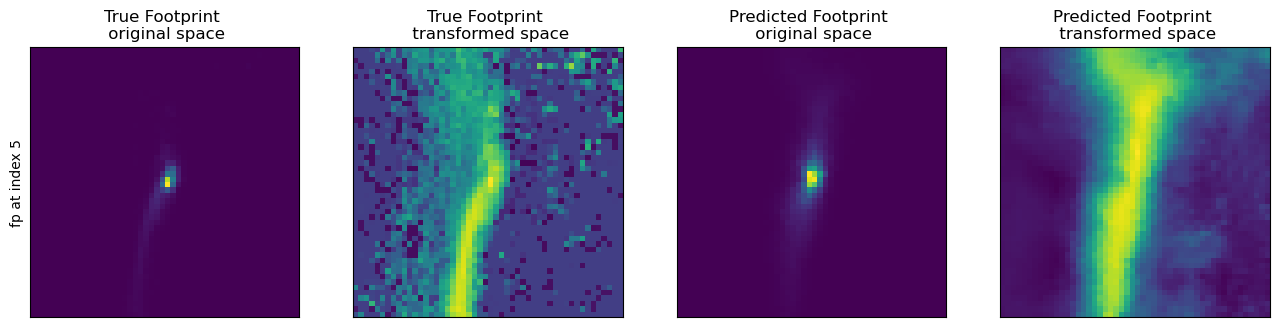

In [34]:
# if predicted footprints have been added using inverse transform, plot_footprints will show them too
idx = 5
test_dataset.plot_footprints(idx)

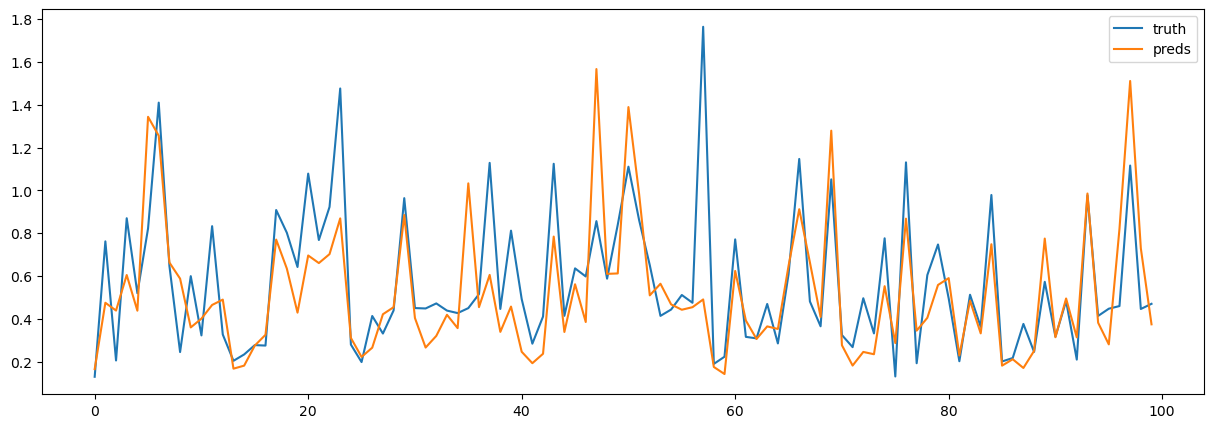

In [38]:
# plot fluxes. window_size controls the number of points plotted, window_n the time window
# ie window_n=0 and window_size=100 will plot points 0-100 and so on
test_dataset.plot_flux(window_n = 0, window_size=100)

# evaluating saved models

In [7]:
from model.evaluation import *

In [10]:
# ModelEv loads prediction files, that have been generated with general_make_prediction.py
model_name = "satellite_50x50_distance"
distance = ModelEv(model_name, size=50, path_to_files="/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/trained_models/")
distance.full_ev() 

loading data from /user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/trained_models/satellite_50x50_distance/predictions/preds_2016*.nc
using validation data: 0[1-3] and test data: *. Checking overlap between the two: True


/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/xarray/core/indexing.py:1227: PerformanceWarning: Slicing with an out-of-order index is generating 403 times more chunks
  return self.array[key]
/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/model/evaluation.py:412: RankWarning: Polyfit may be poorly conditioned
  adjusted_precipitation_bias = corrective_layer_footprint(observed_precip_val, model_precip_val, to_correct=model_precip_test, return_models=False, size=self.size)


<class 'str'>
evaluation for model satellite_50x50_distance
          adj       MAE           MSE    IoU   Dice    Acc     r2  flux_mae  \
0       preds  0.000221  8.298366e-07  62.32  49.21  66.26  46.22     12.23   
1         thr  0.000216  8.319322e-07  45.09  32.71  64.94  37.59     13.57   
2  bias_pbp_q  0.000257  1.125378e-06  59.82  48.21  64.11  26.34     14.94   
3  bias_pbp_l  0.000301  9.675525e-07  55.75  39.76  68.69  23.11     16.29   
4      bias_q  0.000235  9.901909e-07  62.32  49.21  66.26  46.17     12.69   
5      bias_l  0.000243  9.796918e-07  62.65  45.47  70.79  43.57     13.18   
6    bias_thr  0.000229  9.920245e-07  46.11  33.27  65.42  43.85     12.94   
7  bias_thr_l  0.000235  9.809880e-07  43.19  31.69  64.03  42.99     13.13   

     bias    NMAE  
0  4.8434  0.3263  
1  8.7256  0.3623  
2 -0.6496  0.3989  
3  0.8576  0.4349  
4 -0.1233  0.3386  
5  0.4222  0.3519  
6  2.9776  0.3455  
7  1.1585  0.3505  
Column:          Best scoring method:          S

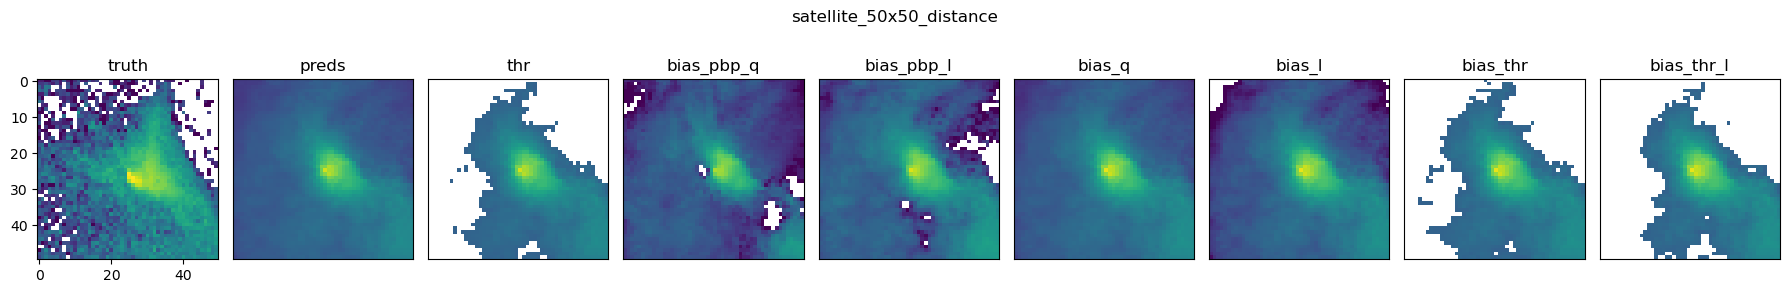

In [11]:
# plot true, predicted and bias-corrected footprints at index n for all evaluated models in list "mods"
mods =  [distance]
n=5
for model in mods:
    model_to_plot = model
    fig, ax = plt.subplots(1,1+len(model_to_plot.variations), figsize=(18,3))

    ax[0].imshow(np.log10(model_to_plot.preds_test.fp.values[n]))
    ax[0].set_title("truth")
    vmax = np.max(np.log10(model_to_plot.preds_test.fp.values[n]))
    vmin = np.min(np.log10(model_to_plot.preds_test.fp.values[n][model_to_plot.preds_test.fp.values[n]>0]))

    fig.suptitle(model_to_plot.model_name)

    for axn, name in enumerate(model_to_plot.variations):
        axn=axn+1
        ax[axn].imshow(np.log10(model_to_plot.variations[name][n]), vmin=vmin, vmax=vmax)
        ax[axn].set_title(name)
        ax[axn].tick_params(left = False, bottom = False, labelbottom=False, labelleft=False) 

    fig.patch.set_facecolor('white')
    plt.tight_layout()
    plt.show()